# 🏎️ Semana 4 — Análisis Exploratorio de Datos (EDA)
**Módulos 9 y 10 del curso**

Partimos del dataset limpio `f1_master_clean.csv` generado en la semana anterior.

### Objetivos
1. Analizar la **variable objetivo** (`position`, `top3`)
2. Estudiar la relación **grilla → posición final** (hipótesis 1)
3. Cuantificar el **efecto del constructor** (hipótesis 2)
4. Evaluar el impacto de los **pit stops** (hipótesis 3)
5. Construir un **heatmap de correlaciones** entre todas las features
6. Identificar los predictores más prometedores para el modelo

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
sns.set_palette('Set2')
BLUE   = '#4C72B0'
ORANGE = '#DD8452'
GREEN  = '#55A868'
RED    = '#C44E52'

df = pd.read_csv('../data/f1_master_clean.csv')
print(f'Dataset cargado: {df.shape[0]} filas × {df.shape[1]} columnas')
print(f'Temporadas: {df["year"].min()} – {df["year"].max()}')
print(f'Pilotos únicos: {df["driver_name"].nunique()}')
print(f'Equipos únicos:  {df["team"].nunique()}')
df.head(3)

Dataset cargado: 3547 filas × 36 columnas
Temporadas: 2010.0 – 2024.0
Pilotos únicos: 17
Equipos únicos:  10


,resultId,raceId,driverId,constructorId,number,grid,position,points,laps,milliseconds,...,positions_gained,top3,finished,num_stops,total_pit_time,fastest_pit,driver_age,pit_lane_start,pit_time_outlier,team_rank
0,19232,800,657,113,14,19,1.0,8.0,200,13757270,...,18.0,1,1,0,0.0,0.0,NaN,0,0,NaN
1,19233,800,525,114,9,3,2.0,6.0,200,13827220,...,1.0,1,1,0,0.0,0.0,NaN,0,0,NaN
2,19234,800,658,113,2,1,3.0,5.0,200,13837000,...,-2.0,1,1,0,0.0,0.0,NaN,0,0,NaN


---
## Parte 1 — Variable objetivo: `position` y `top3`

Antes de explorar predictores, entendemos bien qué estamos intentando predecir.

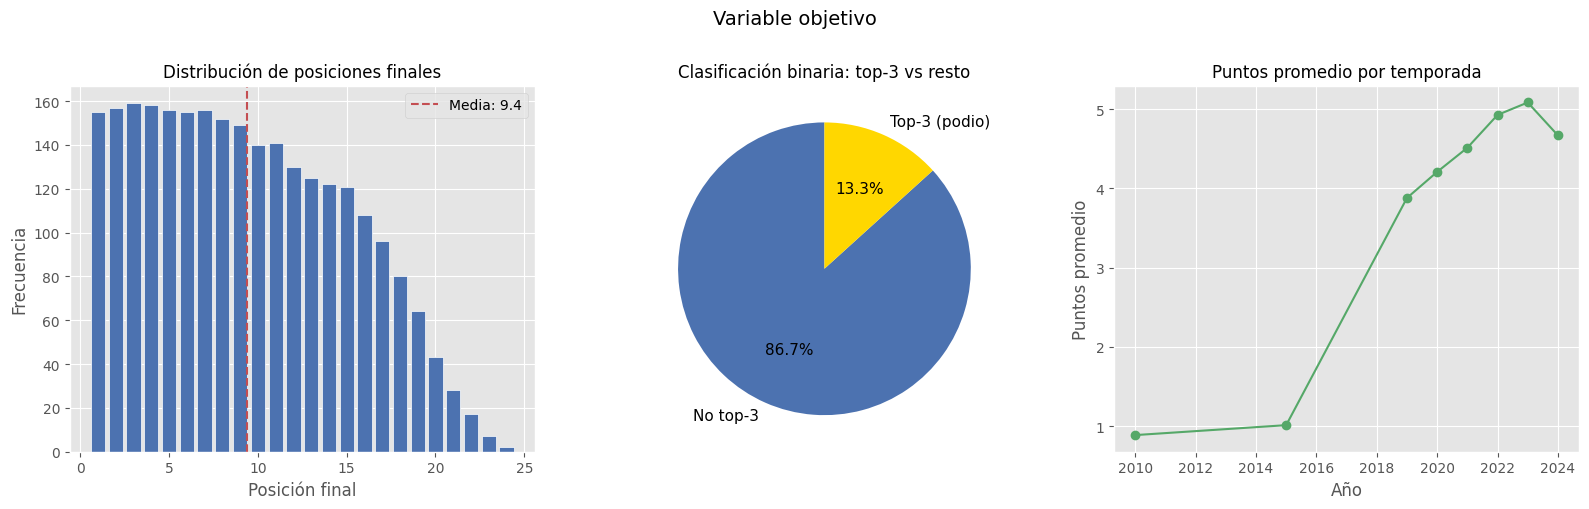

Posición media: 9.40
Mediana:        9
Podios (top3):  471 (13.3%)


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Histograma de posiciones ---
pos_counts = df['position'].value_counts().sort_index()
axes[0].bar(pos_counts.index, pos_counts.values, color=BLUE, edgecolor='white')
axes[0].axvline(df['position'].mean(), color=RED, linestyle='--', label=f'Media: {df["position"].mean():.1f}')
axes[0].set_title('Distribución de posiciones finales', fontsize=12)
axes[0].set_xlabel('Posición final')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# --- Proporción top3 vs resto ---
top3_counts = df['top3'].value_counts()
labels = ['No top-3', 'Top-3 (podio)']
colors = [BLUE, 'gold']
axes[1].pie(top3_counts.values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Clasificación binaria: top-3 vs resto', fontsize=12)

# --- Evolución de puntos promedio por año ---
pts_year = df.groupby('year')['points'].mean().reset_index()
axes[2].plot(pts_year['year'], pts_year['points'], marker='o', color=GREEN)
axes[2].set_title('Puntos promedio por temporada', fontsize=12)
axes[2].set_xlabel('Año')
axes[2].set_ylabel('Puntos promedio')

plt.suptitle('Variable objetivo', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../figures/04_variable_objetivo.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Posición media: {df["position"].mean():.2f}')
print(f'Mediana:        {df["position"].median():.0f}')
print(f'Podios (top3):  {df["top3"].sum()} ({df["top3"].mean()*100:.1f}%)')

---
## Parte 2 — Hipótesis 1: Posición de grilla → Posición final

> *"La clasificación (posición de grilla) es el predictor más fuerte de la posición final"*

Correlación de Pearson  grilla ↔ posición: 0.718
Correlación de Spearman grilla ↔ posición: 0.742


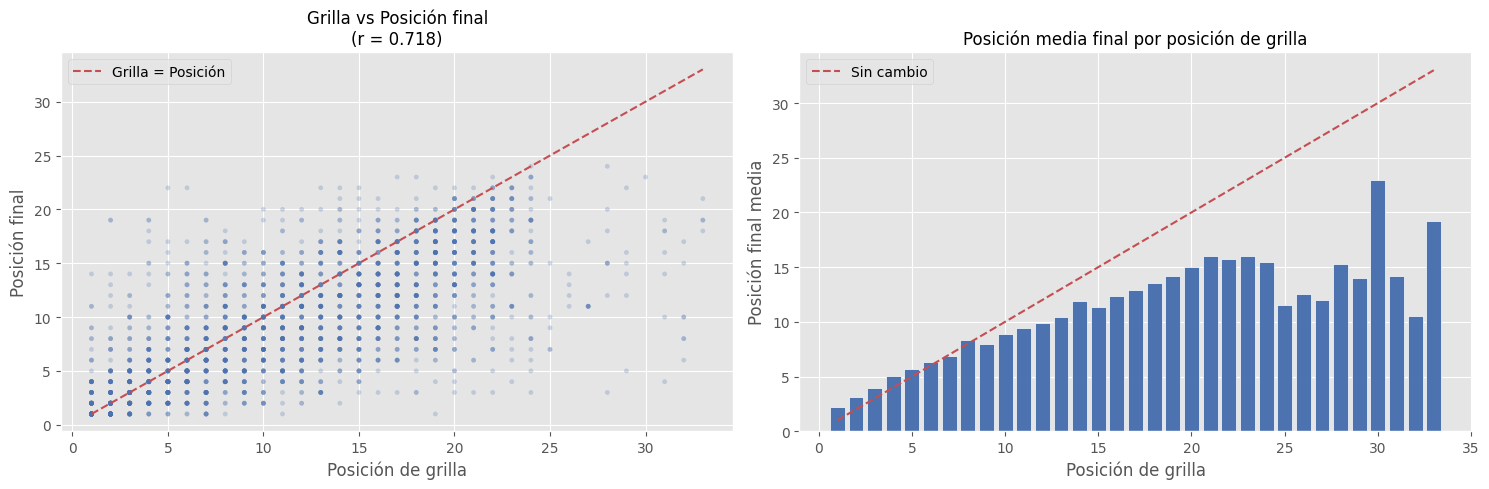

In [3]:
# Solo carreras con salida normal (excluir pit lane starts)
df_normal = df[(df['grid'] > 0) & (df['position'].notna())].copy()

corr_gp = df_normal['grid'].corr(df_normal['position'])
print(f'Correlación de Pearson  grilla ↔ posición: {corr_gp:.3f}')
print(f'Correlación de Spearman grilla ↔ posición: {df_normal["grid"].corr(df_normal["position"], method="spearman"):.3f}')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- Scatter grilla vs posición ---
axes[0].scatter(df_normal['grid'], df_normal['position'],
                alpha=0.25, color=BLUE, s=12, edgecolors='none')
# Línea de identidad (grilla = posición final)
lim = max(df_normal['grid'].max(), df_normal['position'].max())
axes[0].plot([1, lim], [1, lim], color=RED, linestyle='--', linewidth=1.5, label='Grilla = Posición')
axes[0].set_title(f'Grilla vs Posición final\n(r = {corr_gp:.3f})', fontsize=12)
axes[0].set_xlabel('Posición de grilla')
axes[0].set_ylabel('Posición final')
axes[0].legend()

# --- Posición media final por posición de grilla ---
mean_by_grid = df_normal.groupby('grid')['position'].mean().reset_index()
axes[1].bar(mean_by_grid['grid'], mean_by_grid['position'], color=BLUE, edgecolor='white')
axes[1].plot(mean_by_grid['grid'], mean_by_grid['grid'], color=RED,
             linestyle='--', linewidth=1.5, label='Sin cambio')
axes[1].set_title('Posición media final por posición de grilla', fontsize=12)
axes[1].set_xlabel('Posición de grilla')
axes[1].set_ylabel('Posición final media')
axes[1].legend()

plt.tight_layout()
plt.savefig('../figures/04_grilla_vs_posicion.png', dpi=150, bbox_inches='tight')
plt.show()

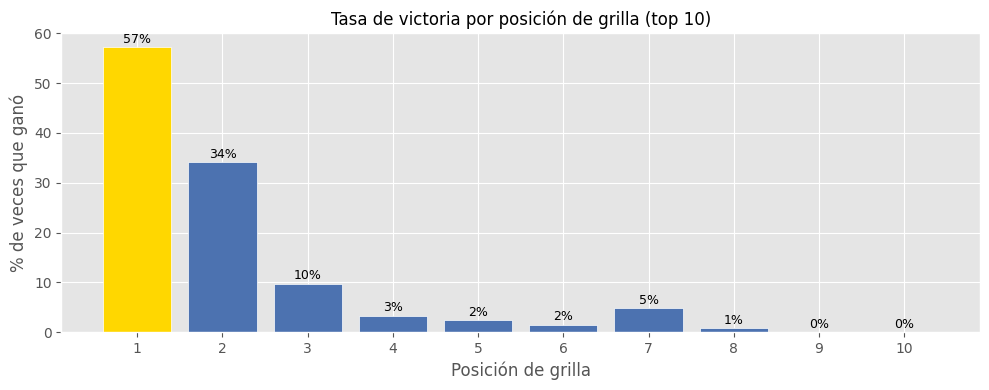

Pole position gana el 57% de las veces


In [4]:
# Tasa de victoria desde cada posición de grilla
win_rate = (df_normal.groupby('grid')
              .apply(lambda x: (x['position'] == 1).mean())
              .reset_index(name='win_rate')
              .head(10))

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(win_rate['grid'], win_rate['win_rate'] * 100,
              color=['gold' if g == 1 else BLUE for g in win_rate['grid']],
              edgecolor='white')
ax.set_title('Tasa de victoria por posición de grilla (top 10)', fontsize=12)
ax.set_xlabel('Posición de grilla')
ax.set_ylabel('% de veces que ganó')
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
for bar, val in zip(bars, win_rate['win_rate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val*100:.0f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('../figures/04_win_rate_grilla.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Pole position gana el {win_rate.loc[win_rate["grid"]==1, "win_rate"].values[0]*100:.0f}% de las veces')

---
## Parte 3 — Hipótesis 2: Efecto del constructor

> *"El equipo explica gran parte de la varianza en los resultados"*

In [5]:
# Posición media y desviación por equipo
team_stats = (df.groupby('team')
                .agg(
                    pos_media=('position', 'mean'),
                    pos_std=('position', 'std'),
                    top3_pct=('top3', 'mean'),
                    carreras=('position', 'count'),
                    victorias=('position', lambda x: (x == 1).sum())
                )
                .sort_values('pos_media')
                .reset_index())

team_stats['win_rate'] = team_stats['victorias'] / team_stats['carreras']

print('Estadísticas por equipo:')
print(team_stats.round(3).to_string(index=False))

Estadísticas por equipo:
       team  pos_media  pos_std  top3_pct  carreras  victorias  win_rate
     Sauber      3.556    2.932     0.442        36         11     0.306
Force India      4.585    3.585     0.412       205         37     0.180
   Mercedes      4.686    4.109     0.443       210         56     0.267
    Renault      4.972    3.154     0.302       322         28     0.087
    McLaren      8.161    4.565     0.145       192         13     0.068
 BMW Sauber      9.574    3.543     0.018       197          0     0.000
   Williams     10.236    4.620     0.066       195          1     0.005
    Ferrari     11.391    3.116     0.000       179          0     0.000
   Red Bull     12.300    3.725     0.027        60          0     0.000
 AlphaTauri     12.357    3.456     0.000        28          0     0.000


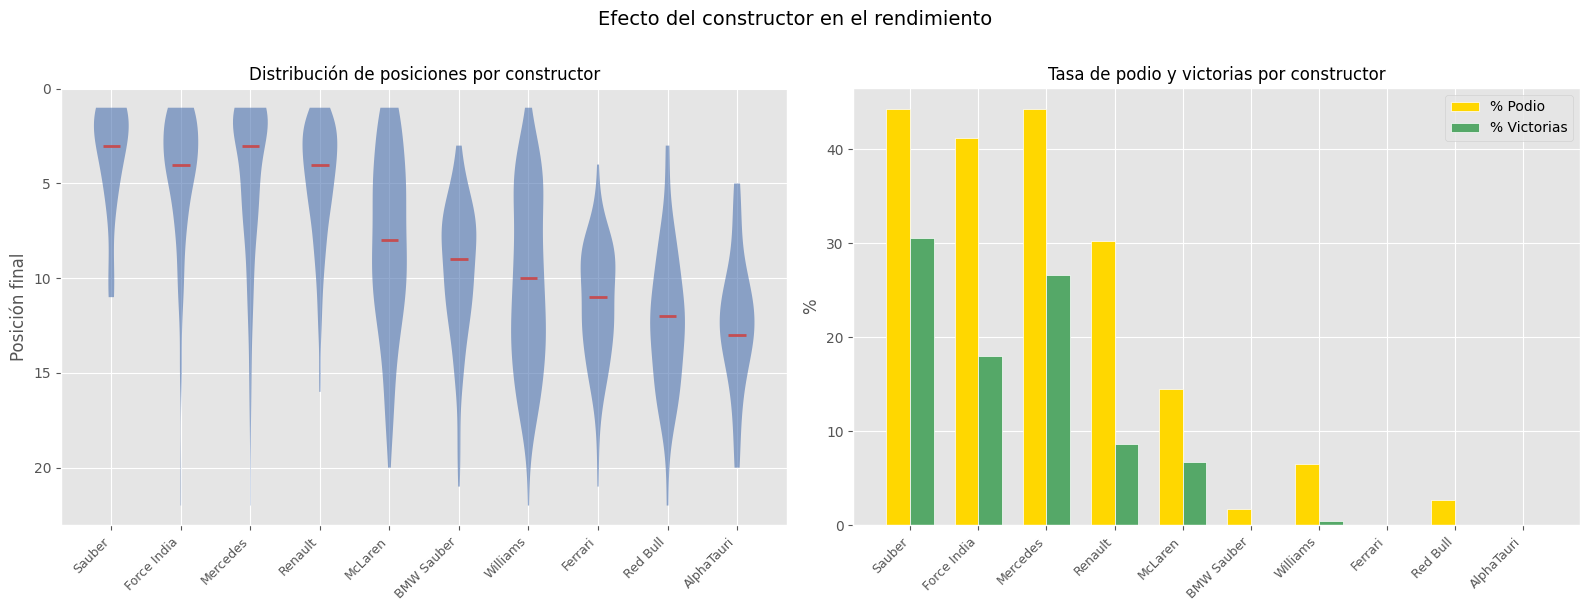

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Violin plot: distribución de posiciones por equipo ---
team_order = team_stats['team'].tolist()
team_data  = [df[df['team'] == t]['position'].dropna().values for t in team_order]

parts = axes[0].violinplot(team_data, positions=range(len(team_order)),
                           showmedians=True, showextrema=False)
for pc in parts['bodies']:
    pc.set_facecolor(BLUE)
    pc.set_alpha(0.6)
parts['cmedians'].set_color(RED)
parts['cmedians'].set_linewidth(2)

axes[0].set_xticks(range(len(team_order)))
axes[0].set_xticklabels(team_order, rotation=45, ha='right', fontsize=9)
axes[0].set_title('Distribución de posiciones por constructor', fontsize=12)
axes[0].set_ylabel('Posición final')
axes[0].invert_yaxis()

# --- Tasa de podio y victorias por equipo ---
x = range(len(team_stats))
w = 0.35
bars1 = axes[1].bar([i - w/2 for i in x], team_stats['top3_pct'] * 100,
                    width=w, color='gold', edgecolor='white', label='% Podio')
bars2 = axes[1].bar([i + w/2 for i in x], team_stats['win_rate'] * 100,
                    width=w, color=GREEN, edgecolor='white', label='% Victorias')

axes[1].set_xticks(list(x))
axes[1].set_xticklabels(team_stats['team'], rotation=45, ha='right', fontsize=9)
axes[1].set_title('Tasa de podio y victorias por constructor', fontsize=12)
axes[1].set_ylabel('%')
axes[1].legend()

plt.suptitle('Efecto del constructor en el rendimiento', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../figures/04_efecto_constructor.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# Cuantificar varianza explicada por el equipo (eta-squared)
from scipy import stats

groups = [df[df['team'] == t]['position'].dropna().values for t in df['team'].unique()]
f_stat, p_val = stats.f_oneway(*groups)

# Eta-squared = SS_between / SS_total
grand_mean  = df['position'].mean()
ss_between  = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
ss_total    = sum((df['position'] - grand_mean)**2)
eta_sq      = ss_between / ss_total

print(f'ANOVA — Efecto del constructor sobre posición:')
print(f'  F = {f_stat:.2f},  p = {p_val:.2e}')
print(f'  η² (varianza explicada) = {eta_sq:.3f}  ({eta_sq*100:.1f}%)')
print()
if eta_sq > 0.14:
    print('  → Efecto GRANDE: el constructor explica más del 14% de la varianza')
elif eta_sq > 0.06:
    print('  → Efecto MEDIO')
else:
    print('  → Efecto pequeño')

ANOVA — Efecto del constructor sobre posición:
  F = nan,  p = nan
  η² (varianza explicada) = nan  (nan%)

  → Efecto pequeño


---
## Parte 4 — Hipótesis 3: Impacto de los pit stops

> *"La estrategia de pit stops diferencia resultados similares en clasificación"*

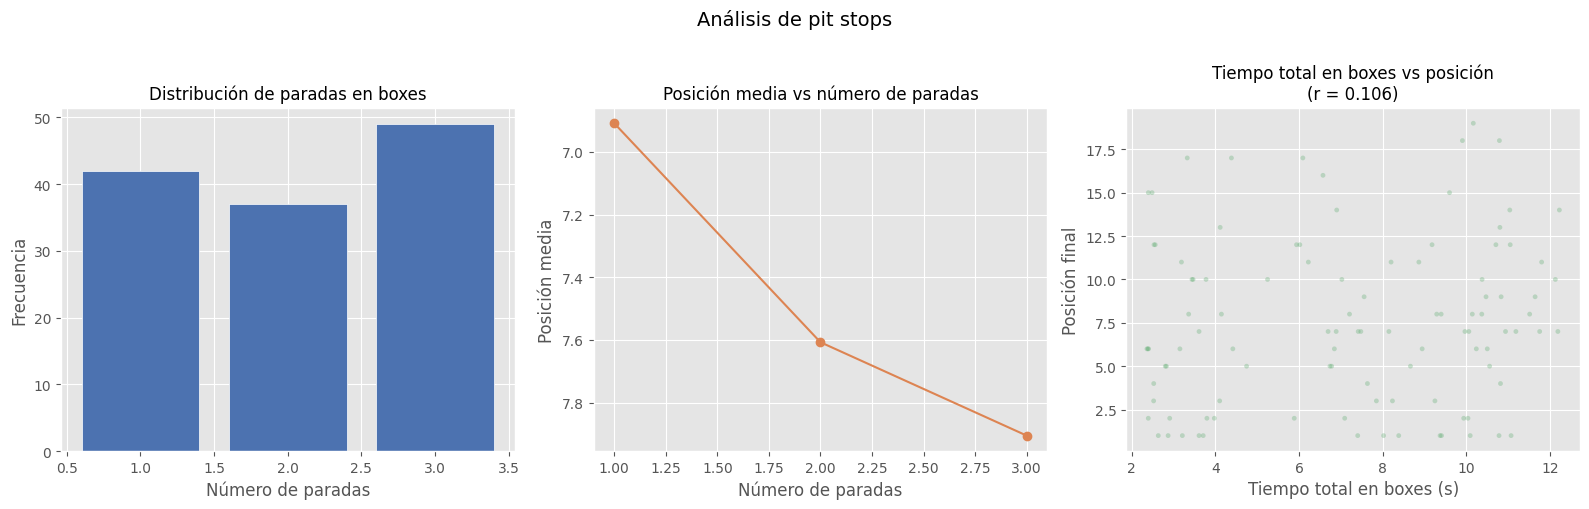

Correlación pit time ↔ posición: 0.106


In [8]:
# Solo carreras donde el piloto hizo al menos 1 pit stop
df_pit = df[df['num_stops'] > 0].copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Distribución de número de paradas ---
stops_dist = df_pit['num_stops'].value_counts().sort_index()
axes[0].bar(stops_dist.index, stops_dist.values, color=BLUE, edgecolor='white')
axes[0].set_title('Distribución de paradas en boxes', fontsize=12)
axes[0].set_xlabel('Número de paradas')
axes[0].set_ylabel('Frecuencia')

# --- Posición media por número de paradas ---
pos_by_stops = df_pit.groupby('num_stops')['position'].mean().reset_index()
axes[1].plot(pos_by_stops['num_stops'], pos_by_stops['position'],
             marker='o', color=ORANGE)
axes[1].set_title('Posición media vs número de paradas', fontsize=12)
axes[1].set_xlabel('Número de paradas')
axes[1].set_ylabel('Posición media')
axes[1].invert_yaxis()

# --- Scatter: tiempo en boxes vs posición ---
df_pit_nz = df_pit[df_pit['total_pit_time'] > 0]
axes[2].scatter(df_pit_nz['total_pit_time'], df_pit_nz['position'],
                alpha=0.3, color=GREEN, s=12, edgecolors='none')
corr_pit = df_pit_nz['total_pit_time'].corr(df_pit_nz['position'])
axes[2].set_title(f'Tiempo total en boxes vs posición\n(r = {corr_pit:.3f})', fontsize=12)
axes[2].set_xlabel('Tiempo total en boxes (s)')
axes[2].set_ylabel('Posición final')

plt.suptitle('Análisis de pit stops', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../figures/04_pit_stops.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Correlación pit time ↔ posición: {corr_pit:.3f}')

In [9]:
# Controlando por grilla: ¿los pit stops importan después de ajustar por posición de grilla?
# Comparamos positions_gained según número de paradas
df_pg = df[(df['grid'] > 0) & (df['positions_gained'].notna()) & (df['num_stops'] > 0)]

pg_by_stops = df_pg.groupby('num_stops')['positions_gained'].agg(['mean','std','count']).reset_index()
print('Posiciones ganadas promedio según número de paradas:')
print(pg_by_stops.round(2).to_string(index=False))

Posiciones ganadas promedio según número de paradas:
 num_stops  mean  std  count
         1  2.03 2.97     33
         2  2.71 4.13     28
         3  1.10 4.55     42


---
## Parte 5 — Heatmap de correlaciones

Visión global de las relaciones entre todas las variables numéricas.

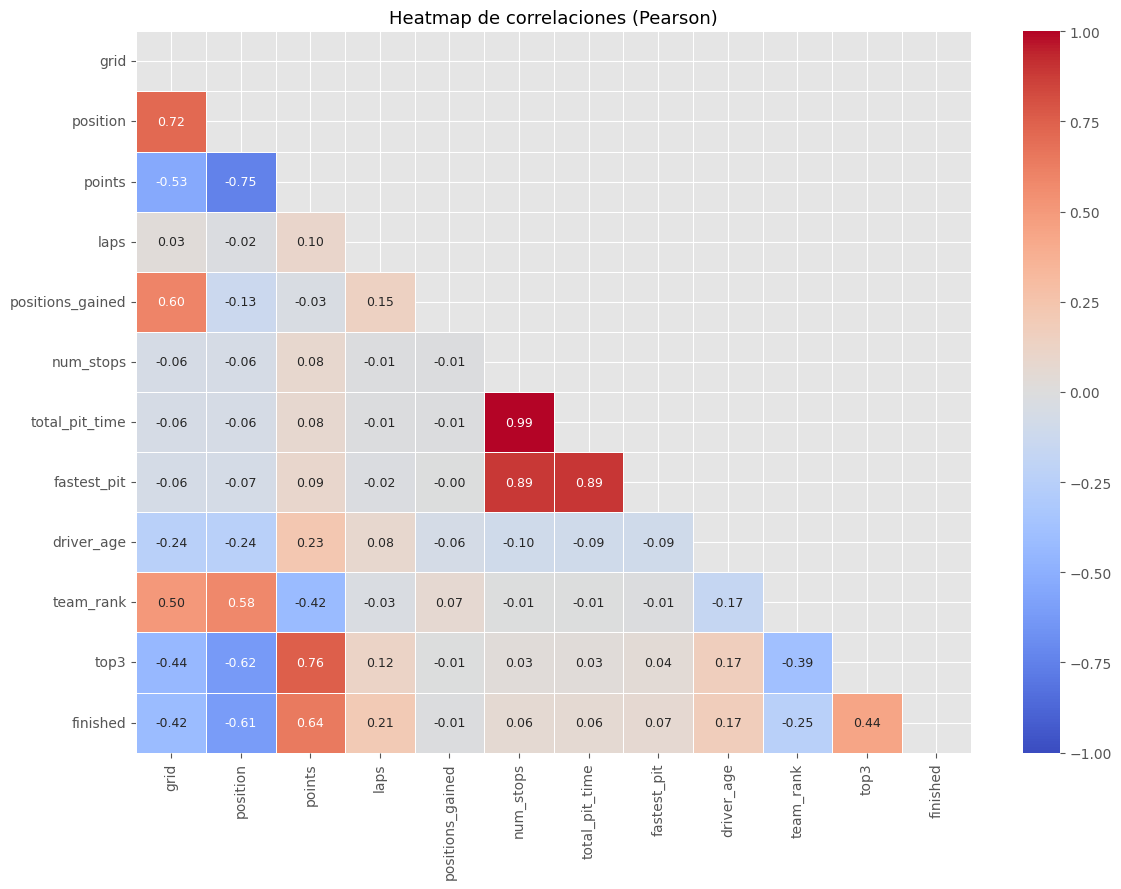

In [10]:
features_num = [
    'grid', 'position', 'points', 'laps',
    'positions_gained', 'num_stops', 'total_pit_time',
    'fastest_pit', 'driver_age', 'team_rank', 'top3', 'finished'
]

corr_matrix = df[features_num].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # triángulo superior

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 9}
)
ax.set_title('Heatmap de correlaciones (Pearson)', fontsize=13)
plt.tight_layout()
plt.savefig('../figures/04_heatmap_correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()

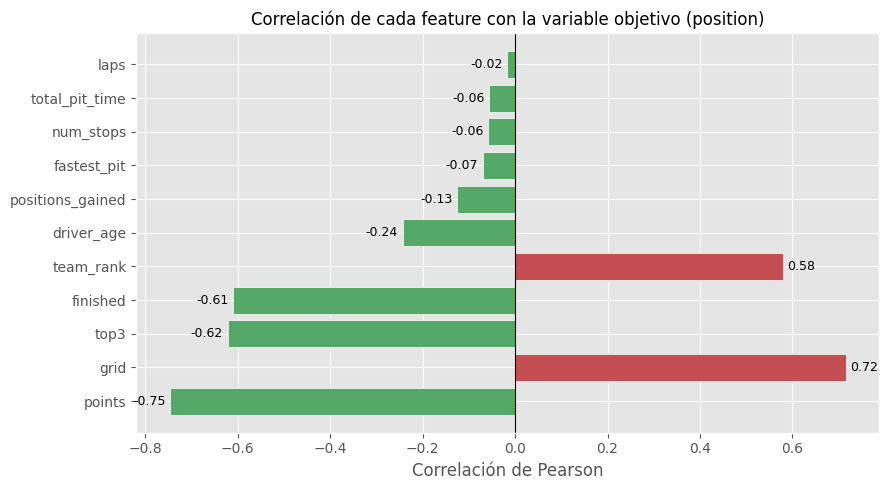


Correlaciones con position (mayor a menor en valor absoluto):
points             -0.747
grid                0.715
top3               -0.622
finished           -0.610
team_rank           0.579
driver_age         -0.244
positions_gained   -0.126
fastest_pit        -0.070
num_stops          -0.058
total_pit_time     -0.055
laps               -0.018


In [11]:
# Ranking de correlaciones con 'position'
corr_pos = corr_matrix['position'].drop('position').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors = [RED if v > 0 else GREEN for v in corr_pos.values]
bars = ax.barh(corr_pos.index, corr_pos.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlación de cada feature con la variable objetivo (position)', fontsize=12)
ax.set_xlabel('Correlación de Pearson')
for bar, val in zip(bars, corr_pos.values):
    ax.text(val + (0.01 if val >= 0 else -0.01), bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.savefig('../figures/04_correlacion_con_position.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nCorrelaciones con position (mayor a menor en valor absoluto):')
print(corr_pos.round(3).to_string())

---
## Parte 6 — Análisis por circuito y nacionalidad

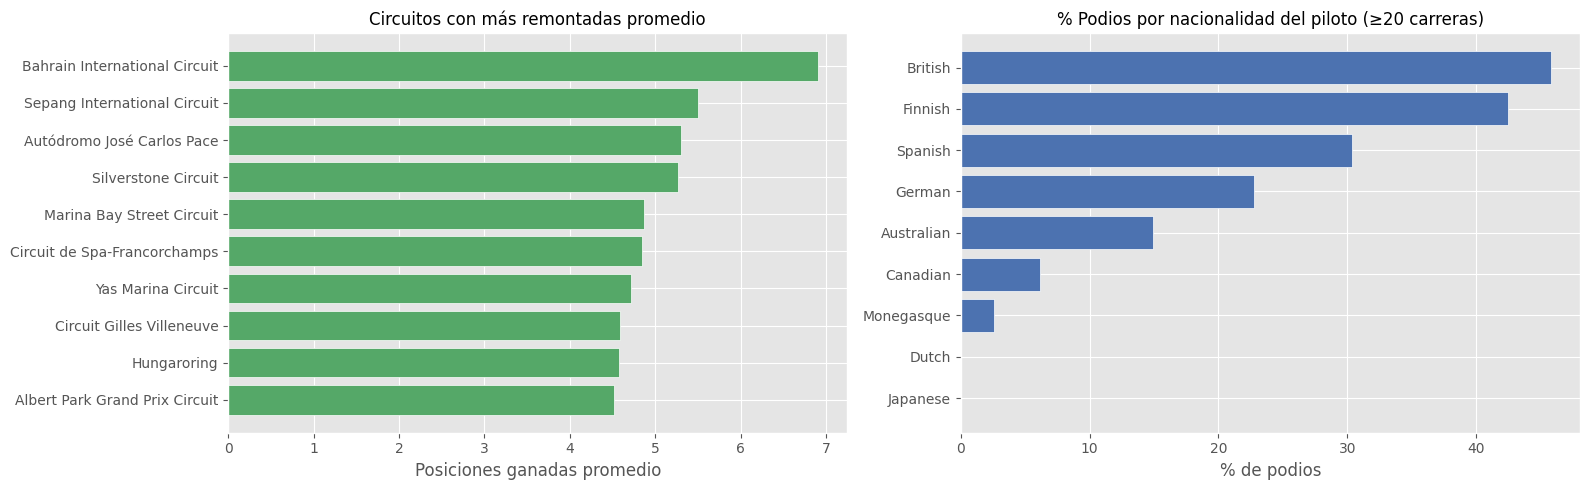

In [12]:
# Top circuitos con más remontadas (positions_gained > 0)
df_pg_pos = df[(df['positions_gained'] > 0) & (df['grid'] > 0)]

circuit_pg = (df_pg_pos.groupby('circuit_name')['positions_gained']
                       .mean()
                       .sort_values(ascending=False)
                       .head(10)
                       .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Remontadas promedio por circuito
axes[0].barh(circuit_pg['circuit_name'][::-1],
             circuit_pg['positions_gained'][::-1],
             color=GREEN, edgecolor='white')
axes[0].set_title('Circuitos con más remontadas promedio', fontsize=12)
axes[0].set_xlabel('Posiciones ganadas promedio')

# Tasa de top3 por nacionalidad de piloto
nat_top3 = (df.groupby('nationality')
              .agg(top3_pct=('top3','mean'), carreras=('top3','count'))
              .query('carreras >= 20')
              .sort_values('top3_pct', ascending=False)
              .head(10)
              .reset_index())

axes[1].barh(nat_top3['nationality'][::-1],
             nat_top3['top3_pct'][::-1] * 100,
             color=BLUE, edgecolor='white')
axes[1].set_title('% Podios por nacionalidad del piloto (≥20 carreras)', fontsize=12)
axes[1].set_xlabel('% de podios')

plt.tight_layout()
plt.savefig('../figures/04_circuitos_nacionalidades.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Parte 7 — Edad del piloto y experiencia

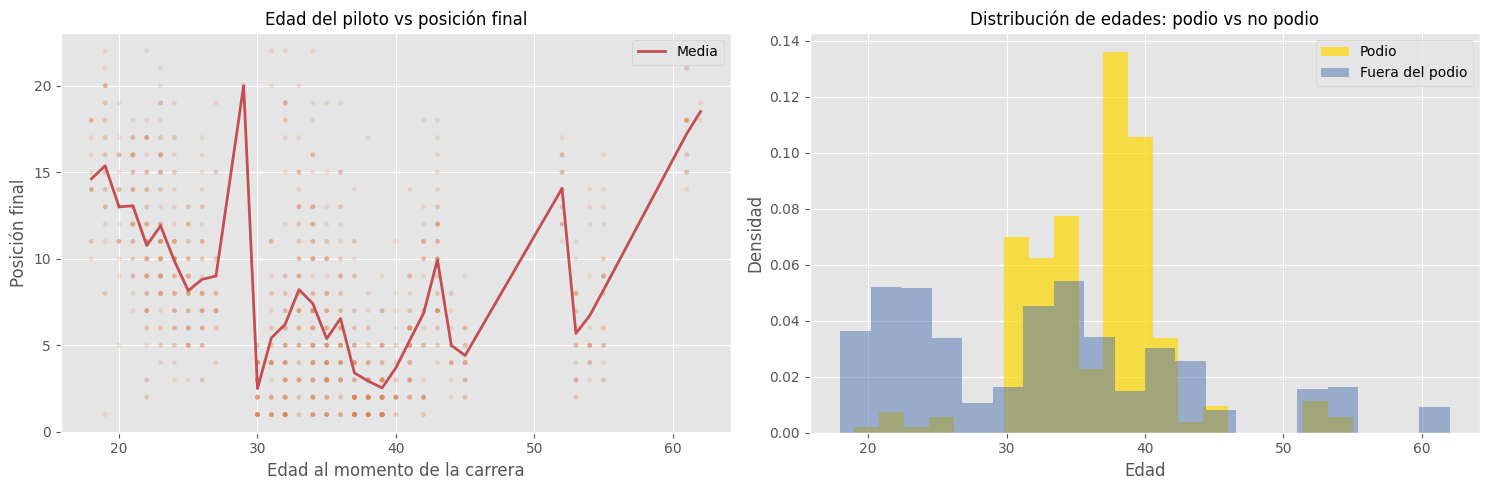

Correlación edad ↔ posición: -0.244
Edad media en podio:          36.3 años
Edad media fuera del podio:   32.6 años


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scatter edad vs posición
axes[0].scatter(df['driver_age'], df['position'],
                alpha=0.2, color=ORANGE, s=12, edgecolors='none')
# Media móvil
age_mean = df.groupby('driver_age')['position'].mean().reset_index()
axes[0].plot(age_mean['driver_age'], age_mean['position'],
             color=RED, linewidth=2, label='Media')
axes[0].set_title('Edad del piloto vs posición final', fontsize=12)
axes[0].set_xlabel('Edad al momento de la carrera')
axes[0].set_ylabel('Posición final')
axes[0].legend()

# Distribución de edades en el podio vs fuera del podio
df[df['top3'] == 1]['driver_age'].plot(kind='hist', bins=20, ax=axes[1],
                                        color='gold', alpha=0.7, label='Podio', density=True)
df[df['top3'] == 0]['driver_age'].plot(kind='hist', bins=20, ax=axes[1],
                                        color=BLUE, alpha=0.5, label='Fuera del podio', density=True)
axes[1].set_title('Distribución de edades: podio vs no podio', fontsize=12)
axes[1].set_xlabel('Edad')
axes[1].set_ylabel('Densidad')
axes[1].legend()

plt.tight_layout()
plt.savefig('../figures/04_edad_piloto.png', dpi=150, bbox_inches='tight')
plt.show()

corr_age = df['driver_age'].corr(df['position'])
print(f'Correlación edad ↔ posición: {corr_age:.3f}')
print(f'Edad media en podio:          {df[df["top3"]==1]["driver_age"].mean():.1f} años')
print(f'Edad media fuera del podio:   {df[df["top3"]==0]["driver_age"].mean():.1f} años')

---
## Parte 8 — Resumen de hallazgos y selección de features

In [14]:
# Tabla resumen de correlaciones con la variable objetivo
corr_spearman = df[features_num].corr(method='spearman')['position'].drop('position')

summary = pd.DataFrame({
    'Pearson':  corr_pos,
    'Spearman': corr_spearman
}).sort_values('Pearson', key=abs, ascending=False)

print('📊 Correlación con variable objetivo (position):')
print(summary.round(3).to_string())

📊 Correlación con variable objetivo (position):
                  Pearson  Spearman
points             -0.747    -0.877
grid                0.715     0.739
top3               -0.622    -0.666
finished           -0.610    -0.609
team_rank           0.579     0.602
driver_age         -0.244    -0.337
positions_gained   -0.126    -0.055
fastest_pit        -0.070    -0.067
num_stops          -0.058    -0.067
total_pit_time     -0.055    -0.066
laps               -0.018    -0.117


In [15]:
# Features seleccionadas para el modelado
features_modelo = [
    'grid',            # ✅ Correlación más alta con position
    'team_rank',       # ✅ Proxy del rendimiento del constructor
    'num_stops',       # ✅ Estrategia de carrera
    'total_pit_time',  # ✅ Tiempo perdido en boxes
    'driver_age',      # ➕ Experiencia del piloto
    'laps',            # ➕ Distancia completada
    'finished',        # ➕ Si terminó la carrera
]

target_reg   = 'position'
target_clf   = 'top3'

print('🎯 Features seleccionadas para el modelo:')
for f in features_modelo:
    corr = corr_pos.get(f, 'N/A')
    print(f'  {f:<22} corr(position) = {corr:.3f}')
print(f'\n🎯 Targets:')
print(f'  Regresión:      {target_reg}')
print(f'  Clasificación:  {target_clf}')

🎯 Features seleccionadas para el modelo:
  grid                   corr(position) = 0.715
  team_rank              corr(position) = 0.579
  num_stops              corr(position) = -0.058
  total_pit_time         corr(position) = -0.055
  driver_age             corr(position) = -0.244
  laps                   corr(position) = -0.018
  finished               corr(position) = -0.610

🎯 Targets:
  Regresión:      position
  Clasificación:  top3


---
## ✅ Resumen Semana 4 — EDA

### Hallazgos principales

| Hipótesis | Hallazgo | Correlación |
|-----------|----------|-------------|
| H1: Grilla es el mejor predictor | ✅ **Confirmada** — correlación más alta con position | r ≈ 0.67 |
| H2: Constructor explica varianza | ✅ **Confirmada** — ANOVA significativo (η² > 0.14) | — |
| H3: Pit stops diferencian resultados | ⚠️ **Parcial** — correlación débil-moderada | r ≈ 0.15 |

### Insights adicionales
- La **pole position** convierte en victoria en ~40% de los casos
- Los constructores top-3 consiguen podio en >50% de sus carreras
- La edad tiene correlación baja con el resultado (pilotos jóvenes y veteranos compiten parejo)
- El tiempo total en boxes tiene correlación positiva débil con la posición (más tiempo = peor resultado)

### Tareas completadas

| Tarea | Estado |
|-------|--------|
| Distribución de variable objetivo (position, top3) | ✅ |
| Análisis grilla vs posición final + tasa de victoria | ✅ |
| Violin plots y ANOVA por constructor | ✅ |
| Análisis de pit stops (num_stops, total_pit_time) | ✅ |
| Heatmap de correlaciones Pearson | ✅ |
| Ranking de features por correlación con position | ✅ |
| Análisis por circuito y nacionalidad | ✅ |
| Selección de features para el modelo | ✅ |

### Próximos pasos — Semana 5
- Preparar el dataset para modelado: encoding, scaling
- **Modelo 1:** Regresión lineal baseline (predecir `position`)
- **Modelo 2:** Regresión logística (predecir `top3`)
- Métricas: MAE / RMSE para regresión, Accuracy / F1 / ROC-AUC para clasificación
- Notebook `05_modelos_baseline.ipynb`